# Instant Model Experiments (Small Neural Network / MLP)

We load `instant_mock.csv`, pick the sensor features, and predict `comfortValue` classes.
We split into train/val/test and run a small grid search using a Multi-Layer Perceptron (Neural Network).
Because Neural Networks are highly sensitive to unscaled data, we use a `Pipeline` to apply a `StandardScaler` before passing the data to the MLP. The network is kept shallow (1 hidden layer) to avoid overfitting on a small dataset.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [5]:
import os
import pandas as pd

data_path = '../../data/processed/instant_mock.csv'

# 'room' is the column that identifies which room the sensor data came from
target_col = 'comfortValue'
group_col = 'room' 
feature_cols = ['humidity', 'light', 'temperature', 'noise', 'co2']

# Load data
df = pd.read_csv(data_path)

# Drop rows with missing values in our critical columns
columns_to_keep = feature_cols + [target_col, group_col]
df = df[columns_to_keep].dropna()

# Make sure the target is a clean class label
if pd.api.types.is_numeric_dtype(df[target_col]):
    df[target_col] = df[target_col].round().astype(int)

print(f"Rooms found: {df[group_col].unique()}")
print(f"Rows after cleaning: {len(df):,}")
display(df.head())

Rooms found: ['Lab 4.2' 'Room 2.5' 'Room 2.12' 'Lab 2.2']
Rows after cleaning: 1,812


,humidity,light,temperature,noise,co2,comfortValue,room
0,4225.0,7.669843,25.1,7.810250,0.001916,4,Lab 4.2
1,4225.0,7.669843,25.1,7.810250,0.001916,5,Lab 4.2
2,4096.0,6.835845,25.2,7.810250,0.001976,3,Lab 4.2
3,4096.0,6.835845,25.2,7.810250,0.001976,4,Lab 4.2
4,3969.0,7.039566,25.3,7.745967,0.001938,4,Lab 4.2


In [6]:
from sklearn.model_selection import GroupShuffleSplit

X = df[feature_cols]
y = df[target_col]
groups = df[group_col]

# 1. Split into Train (2 rooms) and Temp (2 rooms)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_temp, y_temp = X.iloc[temp_idx], y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

# 2. Split Temp into Val (1 room) and Test (1 room)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_val, y_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]

print(f"Train size: {len(X_train):,} (Rooms: {groups.iloc[train_idx].unique()})")
print(f"Val size:   {len(X_val):,} (Rooms: {groups_temp.iloc[val_idx].unique()})")
print(f"Test size:  {len(X_test):,} (Rooms: {groups_temp.iloc[test_idx].unique()})")

Train size: 1,285 (Rooms: ['Room 2.12' 'Lab 2.2'])
Val size:   286 (Rooms: ['Lab 4.2'])
Test size:  241 (Rooms: ['Room 2.5'])


In [7]:
# Create a pipeline that scales the data first, then runs the neural network
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True, validation_fraction=0.15))
])

param_grid = {
    # Testing a single layer with 8 neurons vs a single layer with 16 neurons
    'mlp__hidden_layer_sizes': [(8,), (16,)],
    'mlp__alpha': [0.0001, 0.01], # L2 penalty (regularization term)
    'mlp__learning_rate_init': [0.001, 0.005]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.3f}")

best_model = grid.best_estimator_

def eval_split(name, X_split, y_split):
    preds = best_model.predict(X_split)
    acc = accuracy_score(y_split, preds)
    print(f"{name} accuracy: {acc:.3f}")

eval_split("Validation", X_val, y_val)
eval_split("Test", X_test, y_test)

Best params: {'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (16,), 'mlp__learning_rate_init': 0.005}
Best CV accuracy: 0.482
Validation accuracy: 0.458
Test accuracy: 0.473


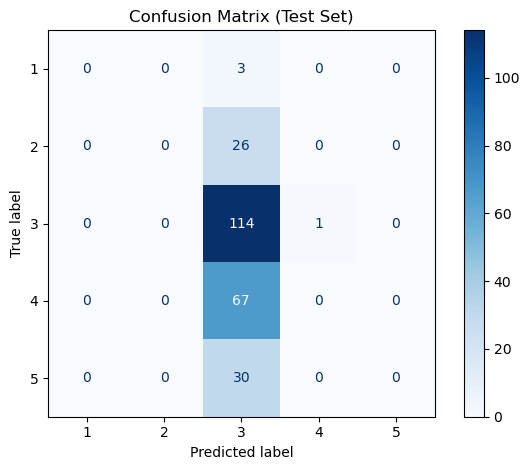

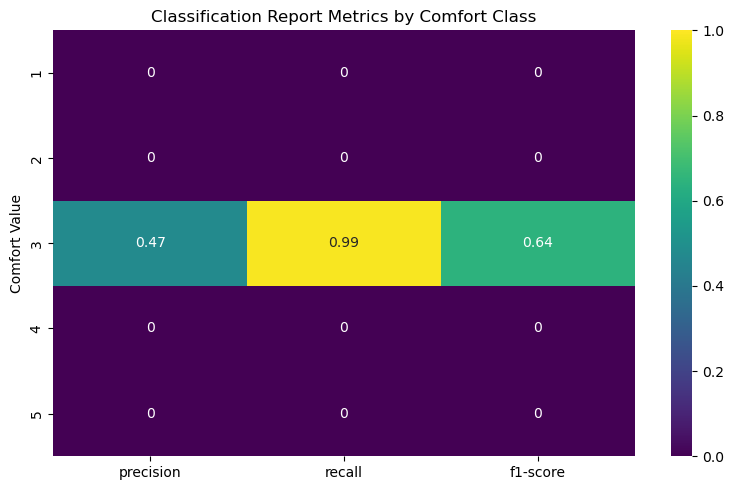

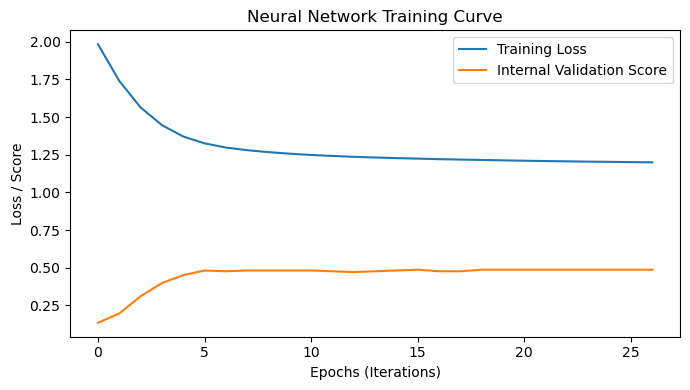

In [8]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

test_preds = best_model.predict(X_test)

# 1. Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds,
    cmap='Blues',
    colorbar=True,
)
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

# 2. Classification Report Heatmap
report = classification_report(y_test, test_preds, output_dict=True, zero_division=0)
if 'accuracy' in report: del report['accuracy']
if 'macro avg' in report: del report['macro avg']
if 'weighted avg' in report: del report['weighted avg']

report_df = pd.DataFrame(report).transpose()
plt.figure(figsize=(8, 5))
sns.heatmap(report_df[['precision', 'recall', 'f1-score']], annot=True, cmap='viridis', vmin=0, vmax=1)
plt.title('Classification Report Metrics by Comfort Class')
plt.ylabel('Comfort Value')
plt.tight_layout()
plt.show()

# 3. Neural Network Training Curve
mlp_model = best_model.named_steps['mlp']
plt.figure(figsize=(7, 4))
plt.plot(mlp_model.loss_curve_, label='Training Loss')
if hasattr(mlp_model, 'validation_scores_'):
    plt.plot(mlp_model.validation_scores_, label='Internal Validation Score')
plt.title('Neural Network Training Curve')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Loss / Score')
plt.legend()
plt.tight_layout()
plt.show()